# EDA - Analyse Exploratoire

Cette EDA vise à transformer les données historiques UNHCR / IDMC en informations utiles pour :

1. comprendre l’évolution des demandes d’asile ;
2. identifier les principaux pays et régions d’origine ;
3. identifier les pays et régions d’accueil sous pression ;
4. analyser les corridors `origine → accueil` ;
5. étudier les décisions d’asile et les formes de protection accordées ;
6. analyser le contexte de déplacement interne IDMC ;
7. identifier les dynamiques persistantes et les signaux précurseurs ;
8. préparer un modèle prédictif de hausse critique à T+1.

### Questions Business

- **QB1** — Comment les demandes d’asile évoluent-elles dans le temps ?
- **QB2** — Quels pays/régions d’origine contribuent le plus aux volumes et aux accélérations ?
- **QB3** — Quels pays/régions d’accueil concentrent les demandes et lesquels combinent volume élevé et croissance forte ?
- **QB4** — Quels corridors origine → accueil présentent les volumes ou accélérations les plus importants ?
- **QB5** — Combien de décisions accordent le statut officiel de réfugié, une autre protection, un rejet ou une clôture ?
- **QB6** — Les hausses sont-elles ponctuelles ou persistantes ?
- **QB7** — Quels signaux disponibles à T caractérisent les segments connaissant une hausse > 15 % à T+1 ?

### Questions prédictives

### Classification
Peut-on prédire si un segment connaîtra une hausse des demandes > 15 % à T+1 ?

### Régression
Peut-on estimer le volume `applied_t1` attendu à T+1 ?

> Principe méthodologique : aucune information future ne peut être utilisée comme feature.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [17]:

DETAIL_PATH = Path("../data/consolidated/dataset_demandes_consolide_detail.csv")
COUNTRY_YEAR_PATH = Path("../data/consolidated/dataset_pays_asile_annee.csv")

if not DETAIL_PATH.exists():
    raise FileNotFoundError(
        "Fichier manquant : dataset_demandes_consolide_detail.csv"
    )

df = pd.read_csv(DETAIL_PATH, low_memory=False)

if COUNTRY_YEAR_PATH.exists():
    df_country_year = pd.read_csv(COUNTRY_YEAR_PATH, low_memory=False)
else:
    df_country_year = None

print("Dataset détaillé :", df.shape)
if df_country_year is not None:
    print("Dataset pays d'asile × année :", df_country_year.shape)


Dataset détaillé : (120597, 50)
Dataset pays d'asile × année : (3807, 16)


### 1. Contrôle qualité de données après consolidation

L’objectif est de vérifier la complétude, l’unicité, la cohérence, la validité et la couverture temporelle.


In [23]:
# Vérifier les données manquantes du dataset demandes d'asiles
print("Période :", int(df["year"].min()), "→", int(df["year"].max()))
print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", df.shape[1])

missing = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2)
}).sort_values("null_pct", ascending=False)

display(missing[missing["null_count"] > 0])

print("\nDoublons stricts :", df.duplicated().sum())

grain = [
    "year", "coo_id", "coa_id",
    "procedure_type", "app_type",
    "dec_level", "app_pc"
]
grain = [c for c in grain if c in df.columns]
print("Doublons au grain métier :", df.duplicated(grain).sum())


Période : 2000 → 2025
Nombre de lignes : 120597
Nombre de colonnes : 50


,null_count,null_pct
returned_idps,120595,100.000
returned_refugees,116753,96.810
resettlement,109371,90.690
naturalisation,108265,89.770
solutions_source_rows,97010,80.440
idmc_total_origin,72038,59.730
recognition_rate,24101,19.980
rejection_rate,24101,19.980
decisions_recognized,24053,19.940
decisions_source_rows,24053,19.940



Doublons stricts : 0
Doublons au grain métier : 0


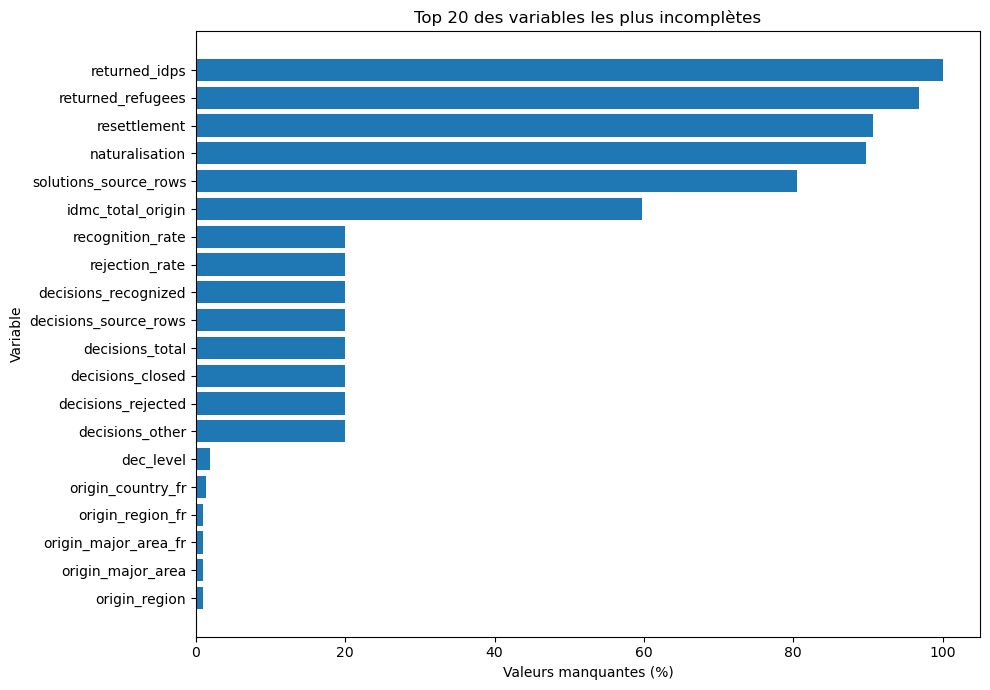

In [24]:
plot_missing = (
    missing[missing["null_count"] > 0]
    .head(20)
    .sort_values("null_pct")
)

plt.figure(figsize=(10, 7))
plt.barh(plot_missing.index, plot_missing["null_pct"])
plt.xlabel("Valeurs manquantes (%)")
plt.ylabel("Variable")
plt.title("Top 20 des variables les plus incomplètes")
plt.tight_layout()
plt.show()


Les variables de **solutions durables** sont les plus incomplètes : `returned_idps` est manquant à environ **100 %**, `returned_refugees` à **96,8 %**, `resettlement` à **90,7 %** et `naturalisation` à **89,8 %**. `idmc_total_origin` est également manquant pour environ **59,7 %** des lignes.

Ces variables ne peuvent pas être utilisées comme indicateurs principaux sans tenir compte de leur couverture. Leur absence ne doit pas être assimilée à une valeur nulle.

Les analyses principales doivent s’appuyer sur les variables les plus fiables ; les solutions durables restent des analyses secondaires et les valeurs manquantes doivent être explicitement signalées.


## 1.1 Contrôle personnes vs dossiers

`app_pc` indique l’unité de comptage :
- `P` = personnes ;
- `C` = dossiers / cas familiaux.

Ces deux unités ne doivent pas être additionnées naïvement lorsqu’on veut interpréter un nombre de personnes.


In [25]:
if "app_pc" in df.columns:
    display(
        df.groupby("app_pc", dropna=False)
          .agg(
              n_lignes=("app_pc", "size"),
              applied_total=("applied", "sum")
          )
          .reset_index()
    )


,app_pc,n_lignes,applied_total
0,C,6962,2710296
1,P,113635,38017103


## 1.2 Validité des décisions et des taux

Contrôle métier :
- `decisions_total` devrait être cohérent avec la somme des quatre issues ;
- les taux doivent être compris entre 0 et 1 ;
- les anomalies sont exportées / marquées pour audit.


In [40]:
decision_cols = [
    "decisions_recognized",
    "decisions_other",
    "decisions_rejected",
    "decisions_closed",
    "decisions_total"
]

if all(c in df.columns for c in decision_cols):
    df["decisions_recomputed"] = (
        df["decisions_recognized"].fillna(0)
        + df["decisions_other"].fillna(0)
        + df["decisions_rejected"].fillna(0)
        + df["decisions_closed"].fillna(0)
    )

    df["decision_total_mismatch"] = (
        df["decisions_total"].notna()
        & (df["decisions_recomputed"] != df["decisions_total"])
    )

    print(
        "Lignes avec incohérence decisions_total :",
        int(df["decision_total_mismatch"].sum())
    )

for col in ["recognition_rate", "rejection_rate"]:
    if col in df.columns:
        valid = df[col].dropna()
        print(
            col,
            "| < 0 :", int((valid < 0).sum()),
            "| > 1 :", int((valid > 1).sum()),
            "| max :", valid.max()
        )


Lignes avec incohérence decisions_total : 362
recognition_rate | < 0 : 0 | > 1 : 0 | max : 1.0
rejection_rate | < 0 : 0 | > 1 : 1 | max : 1.0395569620253164


### Anomalie de taux

Le contrôle de validité met en évidence **une observation avec un `rejection_rate` supérieur à 100 %** : 657 décisions rejetées pour 632 décisions totales, soit environ **103,96 %**.

**Décision Data Quality :** l’observation n’est pas supprimée. Elle doit être conservée, signalée et vérifiée afin de vérifier la cohérence de la source, du périmètre d’agrégation ou de la définition du dénominateur.


### 2.  Évolution temporelle des demandes

Cette section répond à :
**Comment les demandes d’asile évoluent-elles dans le temps et quelles années présentent les principales ruptures ?**


,year,applied_total,n_observations,growth_yoy,absolute_change
0,2000,1092236,2881,NaN,NaN
1,2001,917382,3221,-0.160,"-174,854.000"
2,2002,947639,3271,0.033,"30,257.000"
3,2003,839951,3534,-0.114,"-107,688.000"
4,2004,680256,3501,-0.190,"-159,695.000"
5,2005,672850,3410,-0.011,"-7,406.000"
6,2006,608977,3637,-0.095,"-63,873.000"
7,2007,642273,3599,0.055,"33,296.000"
8,2008,863805,3734,0.345,"221,532.000"
9,2009,937336,3854,0.085,"73,531.000"


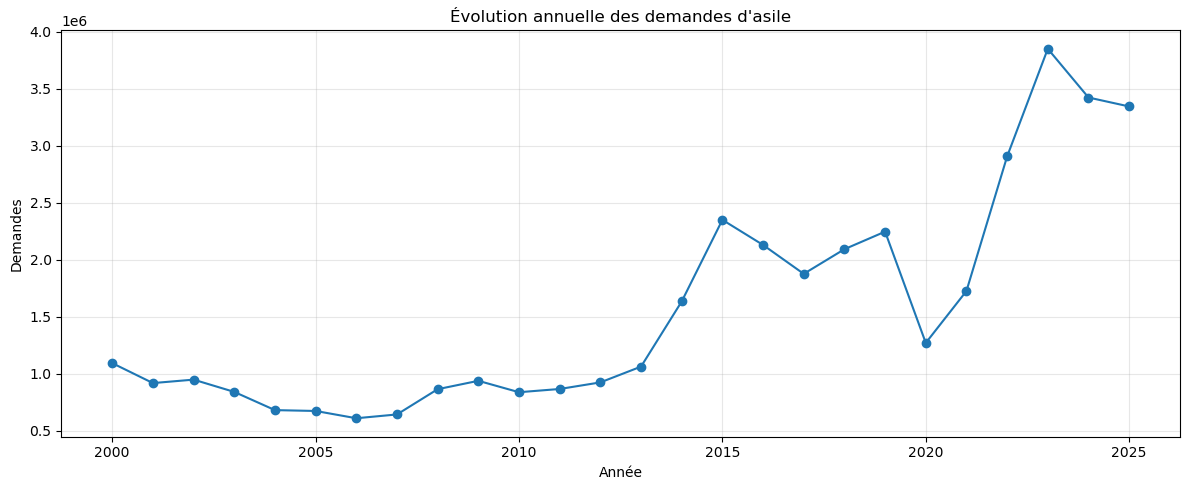

In [41]:
annual = (
    df.groupby("year", as_index=False)
      .agg(
          applied_total=("applied", "sum"),
          n_observations=("applied", "size")
      )
      .sort_values("year")
)

annual["growth_yoy"] = annual["applied_total"].pct_change()
annual["absolute_change"] = annual["applied_total"].diff()

display(annual)

plt.figure(figsize=(12, 5))
plt.plot(annual["year"], annual["applied_total"], marker="o")
plt.xlabel("Année")
plt.ylabel("Demandes")
plt.title("Évolution annuelle des demandes d'asile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Le volume annuel atteint son niveau le plus élevé en **2023 avec 3 848 894 demandes**. Il diminue ensuite à **3 421 776 en 2024**, soit **-11,1 %**, puis à **3 343 203 en 2025**, soit encore **-2,3 %**.

Après une forte phase de hausse jusqu’en 2023, les deux dernières années observées montrent un recul du volume global.

La baisse globale ne signifie pas que tous les pays ou corridors diminuent ; il faut poursuivre l’analyse à un niveau géographique plus fin pour identifier les zones encore en accélération.


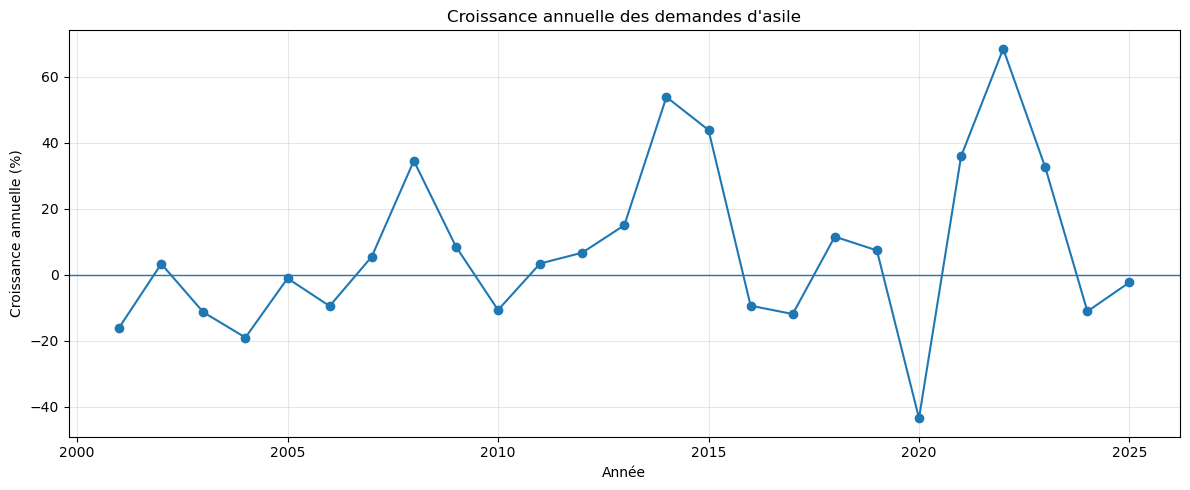

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(annual["year"], annual["growth_yoy"] * 100, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Année")
plt.ylabel("Croissance annuelle (%)")
plt.title("Croissance annuelle des demandes d'asile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La plus forte progression annuelle observée sur la période récente intervient en **2022 : +68,4 %** par rapport à 2021. À l’inverse, **2020 enregistre -43,5 %**, puis une reprise de **+35,9 % en 2021**.

La série présente des ruptures importantes et n’évolue pas de manière régulière.

Cette instabilité temporelle justifie l’utilisation de variables de tendance et de retard (`lag1`, `lag2`, croissance passée) ainsi qu’une validation chronologique.


### 2.1 Distribution de `applied`

La transformation logarithmique améliore la lisibilité sans supprimer les valeurs extrêmes.


count   120,597.000
mean        337.715
std       3,282.608
min           5.000
1%            5.000
5%            5.000
25%           6.000
50%          19.000
75%          89.000
90%         415.000
95%       1,046.000
99%       5,330.000
max     404,142.000
Name: applied, dtype: float64

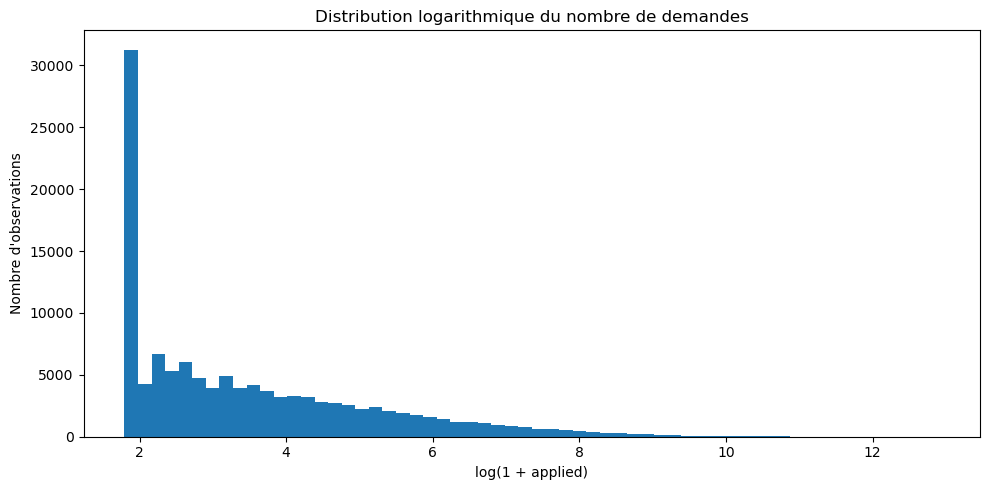

In [43]:
display(
    df["applied"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(df["applied"].dropna()), bins=60)
plt.xlabel("log(1 + applied)")
plt.ylabel("Nombre d'observations")
plt.title("Distribution logarithmique du nombre de demandes")
plt.tight_layout()
plt.show()


La distribution est fortement asymétrique : la **médiane est d’environ 19 demandes par observation**, alors que quelques segments atteignent des volumes très élevés.

La majorité des segments est de petite taille, tandis qu’une minorité concentre une part importante des demandes.

Les fortes valeurs ne doivent pas être supprimées automatiquement. Elles peuvent représenter des événements métier réels. La transformation logarithmique sert uniquement à rendre la distribution lisible.


### 3. Pays et régions d’origine

Objectif : identifier les origines associées aux volumes et aux accélérations les plus importants.


In [44]:
origin_name = (
    "origin_country" if "origin_country" in df.columns
    else "origin_country"
)

origin_year = (
    df.groupby(["year", "coo_id", origin_name], dropna=False, as_index=False)
      .agg(applied=("applied", "sum"))
      .sort_values(["coo_id", "year"])
)

origin_year["growth_yoy"] = (
    origin_year.groupby("coo_id", dropna=False)["applied"].pct_change()
)
origin_year["absolute_change"] = (
    origin_year.groupby("coo_id", dropna=False)["applied"].diff()
)

origin_total = (
    origin_year.groupby(["coo_id", origin_name], dropna=False, as_index=False)
               .agg(applied=("applied", "sum"))
               .sort_values("applied", ascending=False)
)

display(origin_total.head(20))


,coo_id,origin_country,applied
0,2,Afghanistan,2752286
201,207,Venezuela (Bolivarian Republic of),2385750
179,185,Syrian Arab Rep.,2336949
87,92,Iraq,1653234
214,262,Unknown,1496630
171,177,Sudan,1430879
39,41,Dem. Rep. of the Congo,1263884
166,172,Somalia,1161820
42,44,Colombia,1082426
54,56,Eritrea,992288


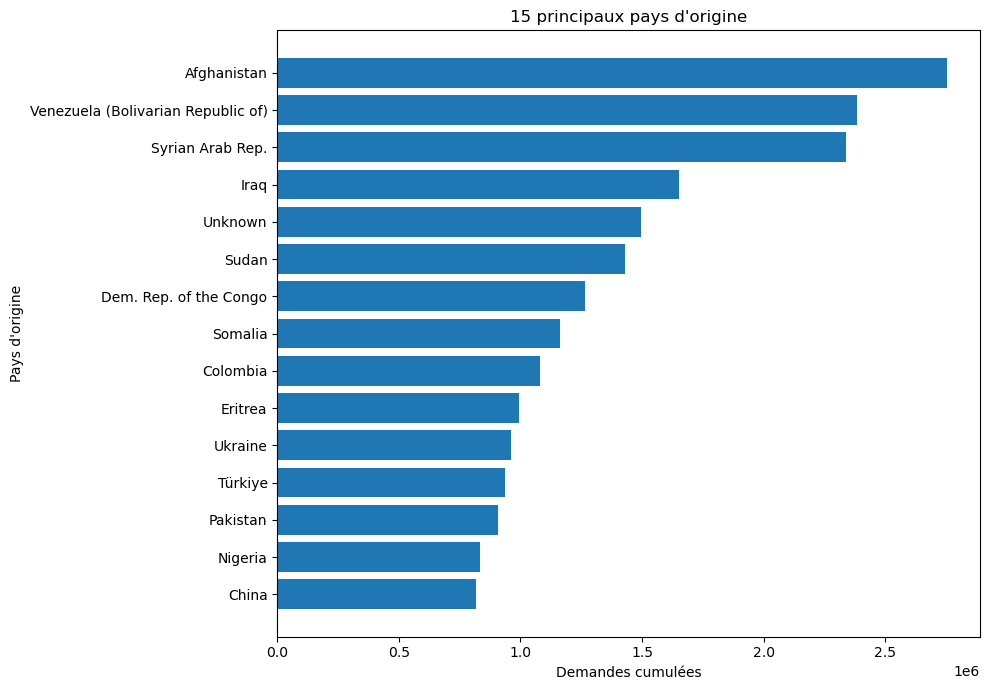

In [45]:
plot_df = origin_total.head(15).sort_values("applied")

plt.figure(figsize=(10, 7))
plt.barh(plot_df[origin_name].astype(str), plot_df["applied"])
plt.xlabel("Demandes cumulées")
plt.ylabel("Pays d'origine")
plt.title("15 principaux pays d'origine")
plt.tight_layout()
plt.show()


Les demandes sont concentrées sur un nombre limité de pays d’origine. 


### 4. Pays d’accueil : volume × croissance

Une croissance relative élevée sur un faible volume n’a pas le même impact qu’une croissance plus modérée sur un volume très important.

L’analyse combine donc :
- volume absolu ;
- croissance relative ;
- variation absolue.


In [46]:
asylum_name = (
    "asylum_country" if "asylum_country" in df.columns
    else "asylum_country"
)

asylum_year = (
    df.groupby(["year", "coa_id", asylum_name], dropna=False, as_index=False)
      .agg(applied=("applied", "sum"))
      .sort_values(["coa_id", "year"])
)

asylum_year["growth_yoy"] = (
    asylum_year.groupby("coa_id", dropna=False)["applied"].pct_change()
)
asylum_year["absolute_change"] = (
    asylum_year.groupby("coa_id", dropna=False)["applied"].diff()
)

latest_year = int(asylum_year["year"].max())
latest_asylum = asylum_year[asylum_year["year"] == latest_year].copy()

display(
    latest_asylum.sort_values("applied", ascending=False).head(20)
)


,year,coa_id,asylum_country,applied,growth_yoy,absolute_change
3801,2025,202,United States of America,911952,0.243,"178,040.000"
3716,2025,72,Germany,338233,-0.067,"-24,305.000"
3671,2025,8,Egypt,292686,-0.331,"-144,543.000"
3711,2025,64,France,214228,-0.022,"-4,720.000"
3714,2025,70,United Kingdom of Great Britain and Northern I...,168185,0.514,"57,078.000"
3782,2025,173,Spain,144387,-0.137,"-22,955.000"
3689,2025,33,Canada,133910,-0.288,"-54,235.000"
3731,2025,94,Italy,133736,-0.157,"-24,852.000"
3697,2025,41,Dem. Rep. of the Congo,99377,15.289,"93,276.000"
3685,2025,27,Brazil,75585,0.109,"7,433.000"


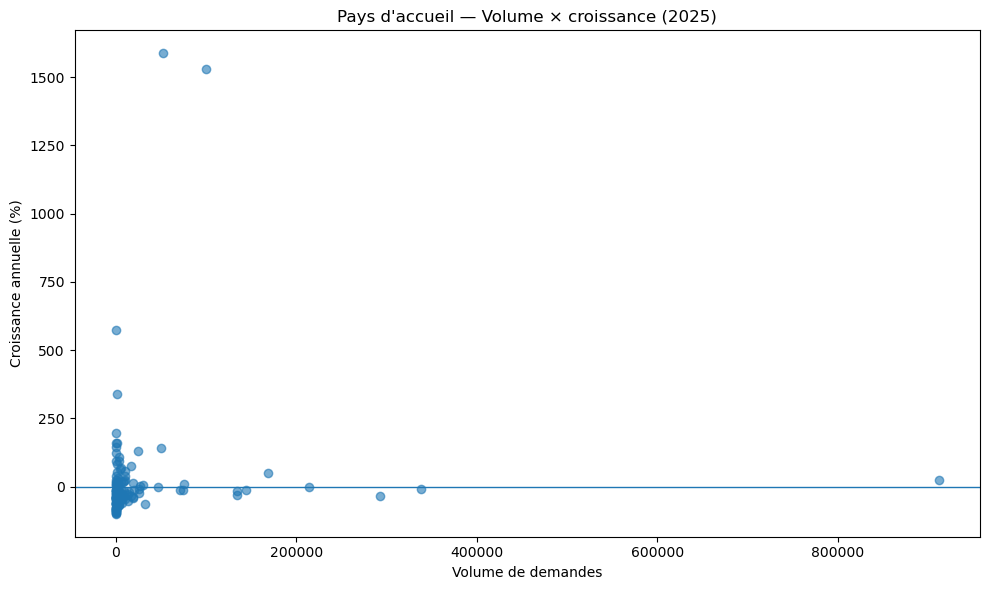

In [47]:
plot_data = latest_asylum[
    latest_asylum["growth_yoy"].replace([np.inf, -np.inf], np.nan).notna()
].copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_data["applied"], plot_data["growth_yoy"] * 100, alpha=0.6)
plt.xlabel("Volume de demandes")
plt.ylabel("Croissance annuelle (%)")
plt.title(f"Pays d'accueil — Volume × croissance ({latest_year})")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()


En **2025**, les États-Unis représentent environ **911 952 demandes** et affichent une croissance de **+24,3 %**, soit environ **+178 040 demandes** par rapport à 2024. Le Royaume-Uni atteint environ **168 185 demandes** avec **+51,4 %**, soit environ **+57 078 demandes**.

À l’inverse, l’Égypte reste à un volume élevé, environ **292 686 demandes**, mais recule de **-33,1 %**, soit environ **-144 543 demandes**.

Le pourcentage de croissance seul ne suffit pas ; volume, croissance relative et variation absolue doivent être lus ensemble.

Les pays combinant un volume élevé et une croissance positive constituent les situations les plus pertinentes à surveiller. Les libellés atypiques observés doivent être nettoyés avant restitution.


### 5. Corridors origine → accueil

Un corridor correspond ici à une combinaison stable :
**pays d’origine → pays d’accueil**.

Objectif :
- identifier les corridors les plus volumineux ;
- mesurer leurs accélérations ;
- distinguer croissance relative et croissance absolue.


In [48]:
corridor = (
    df.groupby(
        ["year", "coo_id", origin_name, "coa_id", asylum_name],
        dropna=False,
        as_index=False
    )
    .agg(applied=("applied", "sum"))
    .sort_values(["coo_id", "coa_id", "year"])
)

corridor["growth_yoy"] = (
    corridor.groupby(["coo_id", "coa_id"], dropna=False)["applied"].pct_change()
)
corridor["absolute_change"] = (
    corridor.groupby(["coo_id", "coa_id"], dropna=False)["applied"].diff()
)

latest_corridors = corridor[corridor["year"] == corridor["year"].max()].copy()

display(
    latest_corridors
    .sort_values("applied", ascending=False)
    .head(20)
)


,year,coo_id,origin_country,coa_id,asylum_country,applied,growth_yoy,absolute_change
86233,2025,262,Unknown,202,United States of America,282797,118.273,"280,426.000"
85425,2025,177,Sudan,8,Egypt,264846,-0.349,"-142,055.000"
86073,2025,207,Venezuela (Bolivarian Republic of),202,United States of America,141616,0.212,"24,749.000"
82293,2025,2,Afghanistan,72,Germany,87715,1.038,"44,676.000"
84508,2025,124,Mexico,202,United States of America,86001,0.579,"31,536.000"
86068,2025,207,Venezuela (Bolivarian Republic of),173,Spain,85413,0.292,"19,279.000"
82867,2025,34,Central African Rep.,41,Dem. Rep. of the Congo,65003,914.535,"64,932.000"
86209,2025,262,Unknown,70,United Kingdom of Great Britain and Northern I...,64052,270.407,"63,816.000"
85816,2025,196,Türkiye,72,Germany,59455,-0.064,"-4,048.000"
83800,2025,81,Haiti,202,United States of America,52130,0.117,"5,467.000"


### 6. Décisions d’asile et protection

Les issues sont distinguées :

- `decisions_recognized` : statut officiel de réfugié ;
- `decisions_other` : autre forme de protection internationale ;
- `decisions_rejected` : rejet ;
- `decisions_closed` : dossier fermé sans décision au fond.

Deux taux sont construits :

- **refugee_recognition_rate** = statut officiel de réfugié / total ;
- **protection_rate** = (statut de réfugié + autre protection) / total.


In [49]:
valid_total = df["decisions_total"].gt(0)

df["refugee_recognition_rate"] = np.where(
    valid_total,
    df["decisions_recognized"] / df["decisions_total"],
    np.nan
)

df["protection_rate"] = np.where(
    valid_total,
    (df["decisions_recognized"] + df["decisions_other"])
    / df["decisions_total"],
    np.nan
)

annual_decisions = (
    df.groupby("year", as_index=False)
      .agg(
          recognized=("decisions_recognized", "sum"),
          other_protection=("decisions_other", "sum"),
          rejected=("decisions_rejected", "sum"),
          closed=("decisions_closed", "sum"),
          decisions_total=("decisions_total", "sum")
      )
)

annual_decisions["refugee_recognition_rate"] = (
    annual_decisions["recognized"] / annual_decisions["decisions_total"]
)
annual_decisions["protection_rate"] = (
    (annual_decisions["recognized"] + annual_decisions["other_protection"])
    / annual_decisions["decisions_total"]
)

display(annual_decisions)


,year,recognized,other_protection,rejected,closed,decisions_total,refugee_recognition_rate,protection_rate
0,2000,"201,349.000","71,935.000","514,209.000","238,376.000","1,026,837.000",0.196,0.266
1,2001,"161,486.000","60,307.000","421,669.000","213,715.000","857,857.000",0.188,0.259
2,2002,"124,448.000","45,370.000","438,881.000","248,192.000","856,821.000",0.145,0.198
3,2003,"129,547.000","38,055.000","435,490.000","276,036.000","878,258.000",0.148,0.191
4,2004,"116,482.000","42,952.000","370,997.000","259,366.000","789,797.000",0.147,0.202
5,2005,"144,123.000","45,804.000","297,113.000","251,130.000","738,170.000",0.195,0.257
6,2006,"131,851.000","48,093.000","267,326.000","188,792.000","636,043.000",0.207,0.283
7,2007,"144,658.000","53,525.000","241,599.000","164,422.000","604,182.000",0.239,0.328
8,2008,"152,715.000","63,622.000","317,066.000","149,969.000","689,102.000",0.222,0.314
9,2009,"224,492.000","50,318.000","311,057.000","152,843.000","738,206.000",0.304,0.372


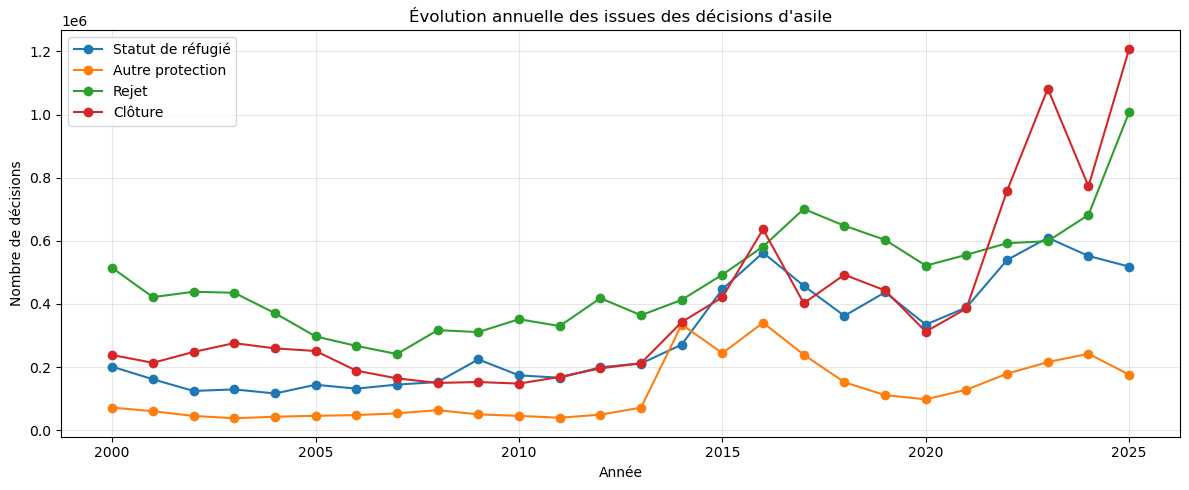

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(annual_decisions["year"], annual_decisions["recognized"], marker="o", label="Statut de réfugié")
plt.plot(annual_decisions["year"], annual_decisions["other_protection"], marker="o", label="Autre protection")
plt.plot(annual_decisions["year"], annual_decisions["rejected"], marker="o", label="Rejet")
plt.plot(annual_decisions["year"], annual_decisions["closed"], marker="o", label="Clôture")
plt.xlabel("Année")
plt.ylabel("Nombre de décisions")
plt.title("Évolution annuelle des issues des décisions d'asile")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Issues des décisions

Sur l’ensemble de la période, le dataset comptabilise environ **7,76 millions de décisions accordant le statut officiel de réfugié**, **3,19 millions d’autres protections**, **12,48 millions de rejets** et **10,13 millions de clôtures**, pour environ **33,58 millions de décisions totales**.

En **2025**, les rejets atteignent environ **1 007 665** et les clôtures environ **1 208 413**, contre **518 469 reconnaissances du statut de réfugié**.

L’issue d’une demande ne se résume pas à une opposition reconnaissance/rejet ; les autres protections et les clôtures représentent également des volumes importants.

La restitution doit présenter séparément ces quatre issues afin de ne pas masquer les différentes formes de décision.


### Décisions et protection

Les données permettent de distinguer quatre issues : **statut officiel de réfugié**, **autre protection internationale**, **rejet** et **clôture sans décision au fond**.

Sur l’ensemble de la période analysée, l’EDA comptabilise environ **7,76 millions de décisions accordant le statut officiel de réfugié**, **3,19 millions d’autres protections**, **12,48 millions de rejets** et **10,13 millions de clôtures**, pour environ **33,58 millions de décisions totales**.

**Vigilance d’interprétation :** ces valeurs représentent des décisions agrégées dans le dataset et ne doivent pas être présentées automatiquement comme un nombre de personnes uniques.


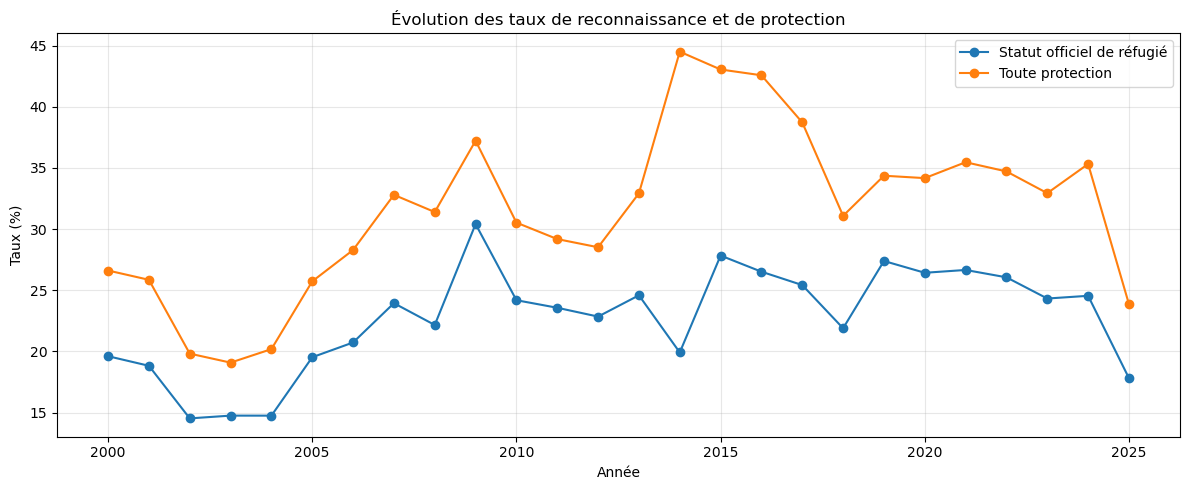

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(
    annual_decisions["year"],
    annual_decisions["refugee_recognition_rate"] * 100,
    marker="o",
    label="Statut officiel de réfugié"
)
plt.plot(
    annual_decisions["year"],
    annual_decisions["protection_rate"] * 100,
    marker="o",
    label="Toute protection"
)
plt.xlabel("Année")
plt.ylabel("Taux (%)")
plt.title("Évolution des taux de reconnaissance et de protection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Taux de reconnaissance et de protection

Le taux de reconnaissance du statut de réfugié varie sensiblement dans le temps. Il atteint environ **24,5 % en 2024**, puis **17,8 % en 2025**. Lorsque les autres formes de protection sont incluses, le taux global de protection est d’environ **35,3 % en 2024** et **23,9 % en 2025**.

Le statut officiel de réfugié et les autres protections internationales doivent être distingués, car ils ne mesurent pas la même issue.


Deux indicateurs doivent être distingués :

- **Taux de reconnaissance du statut de réfugié** = `decisions_recognized / decisions_total` ;
- **Taux global de protection** = `(decisions_recognized + decisions_other) / decisions_total`.

Parler uniquement de « décisions positives » masquerait la différence entre l’octroi du statut officiel de réfugié et les autres formes de protection internationale.


### 6.1 Pays d’origine avec le plus de statuts de réfugié accordés


In [52]:
recognized_origin = (
    df.groupby(["coo_id", origin_name], dropna=False, as_index=False)
      .agg(
          recognized=("decisions_recognized", "sum"),
          decisions_total=("decisions_total", "sum")
      )
)

recognized_origin["refugee_recognition_rate"] = np.where(
    recognized_origin["decisions_total"] > 0,
    recognized_origin["recognized"] / recognized_origin["decisions_total"],
    np.nan
)

display(
    recognized_origin
    .sort_values("recognized", ascending=False)
    .head(20)
)


,coo_id,origin_country,recognized,decisions_total,refugee_recognition_rate
179,185,Syrian Arab Rep.,"913,323.000","2,220,716.000",0.411
0,2,Afghanistan,"733,773.000","2,554,817.000",0.287
39,41,Dem. Rep. of the Congo,"534,341.000","1,081,775.000",0.494
54,56,Eritrea,"512,820.000","896,908.000",0.572
87,92,Iraq,"442,075.000","1,631,904.000",0.271
166,172,Somalia,"376,311.000","929,721.000",0.405
130,135,Myanmar,"310,538.000","493,839.000",0.629
86,91,Iran (Islamic Rep. of),"276,599.000","739,666.000",0.374
201,207,Venezuela (Bolivarian Republic of),"246,162.000","1,064,720.000",0.231
171,177,Sudan,"233,732.000","563,798.000",0.415


### 6.2 Pays d’accueil ayant accordé le plus de statuts de réfugié


In [53]:
recognized_asylum = (
    df.groupby(["coa_id", asylum_name], dropna=False, as_index=False)
      .agg(
          recognized=("decisions_recognized", "sum"),
          other_protection=("decisions_other", "sum"),
          rejected=("decisions_rejected", "sum"),
          decisions_total=("decisions_total", "sum")
      )
)

recognized_asylum["refugee_recognition_rate"] = np.where(
    recognized_asylum["decisions_total"] > 0,
    recognized_asylum["recognized"] / recognized_asylum["decisions_total"],
    np.nan
)

display(
    recognized_asylum
    .sort_values("recognized", ascending=False)
    .head(20)
)


,coa_id,asylum_country,recognized,other_protection,rejected,decisions_total,refugee_recognition_rate
59,72,Germany,"1,062,182.000","798,618.000","1,786,680.000","5,068,927.000",0.210
174,202,United States of America,"700,744.000","2,294.000","1,003,146.000","3,855,291.000",0.182
53,64,France,"509,344.000","206,042.000","2,140,927.000","2,975,409.000",0.171
27,33,Canada,"487,820.000",0.000,"377,889.000","1,013,308.000",0.481
171,199,Uganda,"393,652.000",0.000,"52,543.000","503,549.000",0.782
57,70,United Kingdom of Great Britain and Northern I...,"385,154.000","111,939.000","832,139.000","1,604,331.000",0.240
107,127,Malaysia,"277,026.000","23,837.000","31,563.000","400,931.000",0.691
62,76,Greece,"211,582.000","38,298.000","394,448.000","962,384.000",0.220
9,12,Austria,"204,811.000","66,419.000","209,919.000","744,433.000",0.275
169,196,Türkiye,"204,744.000",0.000,"71,827.000","678,122.000",0.302


### 6.3 Niveau décisionnel

Analyse des résultats selon `dec_level` :
- `FI` : première instance ;
- `AR` : réexamen administratif ;
- `JR` : contrôle judiciaire.


In [54]:
if "dec_level" in df.columns:
    by_level = (
        df.groupby("dec_level", dropna=False, as_index=False)
          .agg(
              recognized=("decisions_recognized", "sum"),
              other_protection=("decisions_other", "sum"),
              rejected=("decisions_rejected", "sum"),
              closed=("decisions_closed", "sum"),
              decisions_total=("decisions_total", "sum")
          )
    )

    by_level["refugee_recognition_rate"] = np.where(
        by_level["decisions_total"] > 0,
        by_level["recognized"] / by_level["decisions_total"],
        np.nan
    )

    display(by_level)


,dec_level,recognized,other_protection,rejected,closed,decisions_total,refugee_recognition_rate
0,AR,"358,151.000","71,790.000","1,766,383.000","591,053.000","2,801,959.000",0.128
1,EO,"287,965.000","2,294.000","531,980.000","928,989.000","1,751,272.000",0.164
2,FA,"784,735.000","165,095.000","640,454.000","985,369.000","2,575,645.000",0.305
3,FI,"4,876,929.000","2,001,360.000","7,452,692.000","5,131,553.000","19,464,883.000",0.251
4,IN,"374,459.000",0.000,"457,073.000","1,121,737.000","1,953,272.000",0.192
5,JR,"45,965.000","51,750.000","362,801.000","417,194.000","878,041.000",0.052
6,RA,"137,016.000","47,796.000","123,201.000","493,380.000","801,393.000",0.171
7,SP,931.000,36.000,"5,194.000","4,136.000","10,297.000",0.090
8,TA,"135,293.000","440,617.000","3,479.000","36,523.000","615,912.000",0.220
9,NaN,"762,866.000","408,770.000","1,135,787.000","418,079.000","2,725,502.000",0.280


### 7. Contexte IDMC — déplacements internes

`idmc_total_origin` représente le stock de personnes déplacées à l’intérieur de leur pays d’origine en raison de conflits ou violences.

L’objectif est de rechercher une **association** avec les demandes d’asile, sans conclure à une causalité.


Observations origine-année avec IDMC exploitable : 898
Corrélation de Spearman IDMC / demandes : 0.5157615733522579


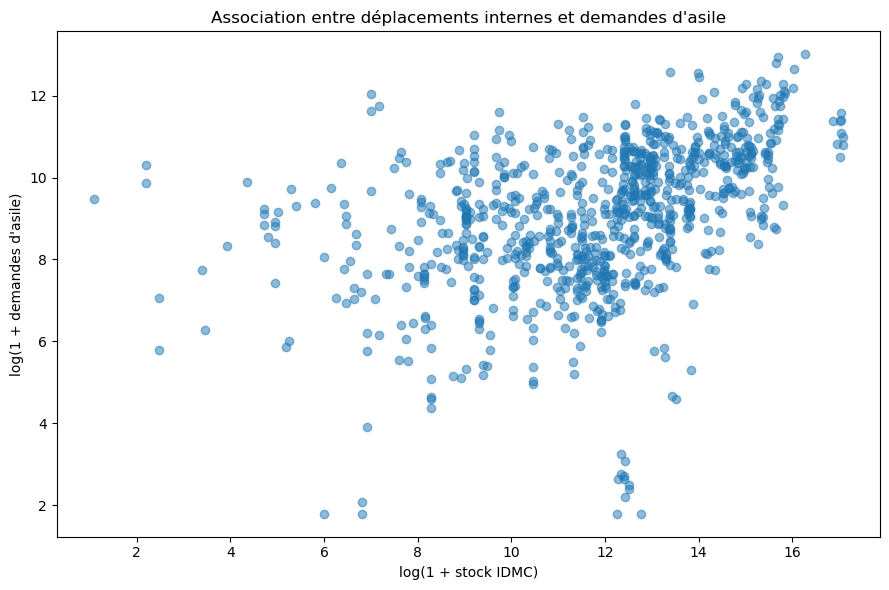

In [55]:
if "idmc_total_origin" in df.columns:
    idmc_analysis = (
        df.groupby(["year", "coo_id", origin_name], dropna=False, as_index=False)
          .agg(
              applied=("applied", "sum"),
              idmc_total_origin=("idmc_total_origin", "max")
          )
    )

    valid = idmc_analysis.dropna(subset=["idmc_total_origin", "applied"]).copy()

    print("Observations origine-année avec IDMC exploitable :", len(valid))
    print(
        "Corrélation de Spearman IDMC / demandes :",
        valid[["idmc_total_origin", "applied"]]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    plt.figure(figsize=(9, 6))
    plt.scatter(
        np.log1p(valid["idmc_total_origin"]),
        np.log1p(valid["applied"]),
        alpha=0.5
    )
    plt.xlabel("log(1 + stock IDMC)")
    plt.ylabel("log(1 + demandes d'asile)")
    plt.title("Association entre déplacements internes et demandes d'asile")
    plt.tight_layout()
    plt.show()


Sur les observations origine-année disposant des deux mesures, la corrélation de Spearman entre `idmc_total_origin` et le nombre de demandes d’asile est d’environ **0,52**.

Les pays présentant des stocks importants de déplacés internes ont tendance à être associés à des volumes plus importants de demandes d’asile, mais la relation n’est ni parfaite ni suffisante pour établir une causalité.

**Implication ML :** `idmc_total_origin` peut être testé comme variable explicative, uniquement si sa valeur est effectivement disponible au moment de la prédiction T=0.


`idmc_total_origin` apporte un contexte sur le niveau de déplacement interne dans le pays d’origine. Son rapprochement avec les demandes d’asile permet de rechercher si les pays présentant de forts déplacements internes sont également associés à davantage de demandes d’asile à l’étranger.

**Vigilance :** cette analyse mesure une **association statistique**. Elle ne permet pas, à elle seule, de conclure qu’une hausse des déplacements internes cause une hausse des demandes d’asile.


### 8. Persistance des dynamiques

*Est-ce qu’une hausse des demandes d’asile continue plusieurs années de suite, ou est-ce seulement une hausse ponctuelle ?*

Le Feature Engineering temporel vise à distinguer :
- un choc ponctuel ;
- une tendance persistante ;
- une forte volatilité.


In [58]:
SEGMENT = [
    "coo_id", "coa_id",
    "procedure_type", "app_type",
    "dec_level", "app_pc"
]
SEGMENT = [c for c in SEGMENT if c in df.columns]

temporal = df.sort_values(SEGMENT + ["year"]).copy()

g = temporal.groupby(SEGMENT, dropna=False)

temporal["applied_lag1"] = g["applied"].shift(1)
temporal["applied_lag2"] = g["applied"].shift(2)

temporal["growth_past_1"] = np.where(
    temporal["applied_lag1"].gt(0),
    (temporal["applied"] - temporal["applied_lag1"])
    / temporal["applied_lag1"],
    np.nan
)

temporal["growth_past_2"] = np.where(
    temporal["applied_lag2"].gt(0),
    (temporal["applied_lag1"] - temporal["applied_lag2"])
    / temporal["applied_lag2"],
    np.nan
)

temporal["two_consecutive_increases"] = (
    temporal["growth_past_1"].gt(0)
    & temporal["growth_past_2"].gt(0)
).astype("Int8")

display(
    temporal[
        ["year", *SEGMENT, "applied",
         "applied_lag1", "applied_lag2",
         "growth_past_1", "growth_past_2",
         "two_consecutive_increases"]
    ].head(20)
)


,year,coo_id,coa_id,procedure_type,app_type,dec_level,app_pc,applied,applied_lag1,applied_lag2,growth_past_1,growth_past_2,two_consecutive_increases
43440,2015,2,3,G,N,FI,P,5,NaN,NaN,NaN,NaN,0
45853,2016,2,3,G,N,FI,P,64,5.000,NaN,11.800,NaN,0
48291,2017,2,3,G,N,FI,P,29,64.000,5.000,-0.547,11.800,0
50693,2018,2,3,G,N,FI,P,36,29.000,64.000,0.241,-0.547,0
53216,2019,2,3,G,N,FI,P,5,36.000,29.000,-0.861,0.241,0
58128,2021,2,3,G,N,FI,P,5,5.000,36.000,0.000,-0.861,0
60495,2022,2,3,G,N,FI,P,13,5.000,5.000,1.600,0.000,0
63448,2023,2,3,G,N,FI,P,5,13.000,5.000,-0.615,1.600,0
69300,2025,2,3,G,N,FI,P,9,5.000,13.000,0.800,-0.615,0
93077,2000,2,3,G,V,FI,C,5,NaN,NaN,NaN,NaN,0


### 9. Construction de la cible prédictive T+1

La cible vaut 1 uniquement si :
- le même segment existe exactement à T+1 ;
- `applied` augmente de plus de 15 %.

Une absence de T+1 reste **non labellisable** et n’est jamais transformée artificiellement en classe 0.


In [60]:
target_df = temporal.copy()

target_df["year_t1"] = (
    target_df.groupby(SEGMENT, dropna=False)["year"].shift(-1)
)
target_df["applied_t1"] = (
    target_df.groupby(SEGMENT, dropna=False)["applied"].shift(-1)
)

target_df["valid_t1"] = target_df["year_t1"].eq(target_df["year"] + 1)

target_df["growth_t1"] = np.where(
    target_df["valid_t1"] & target_df["applied"].gt(0),
    (target_df["applied_t1"] - target_df["applied"])
    / target_df["applied"],
    np.nan
)

TARGET = "hausse_critique_demandes_t1"

target_df[TARGET] = pd.Series(
    pd.NA,
    index=target_df.index,
    dtype="Int8"
)

eligible = target_df["growth_t1"].notna()

target_df.loc[eligible, TARGET] = (
    target_df.loc[eligible, "growth_t1"] > 0.15
).astype("Int8")

print("Observations labellisées :", int(eligible.sum()))
print("Observations non labellisables :", int((~eligible).sum()))
print("Taux de labellisation :", f"{eligible.mean():.2%}")

display(
    target_df[TARGET]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .to_frame("count")
)



Observations labellisées : 80032
Observations non labellisables : 40565
Taux de labellisation : 66.36%


,count
classe,
0,48424
<NA>,40565
1,31608


La cible est calculable pour **80 032 observations**, soit **66,36 %** du dataset détaillé.

Les **40 565** lignes restantes ne sont pas transformées en classe 0 :
- soit aucune observation suivante n’existe ;
- soit la prochaine observation disponible n’est pas exactement T+1.

C’est une règle essentielle pour éviter de fabriquer artificiellement des labels.

### 10. Signaux précurseurs des hausses critiques

On compare les caractéristiques observables à T entre :
- classe 0 : hausse ≤ 15 % ;
- classe 1 : hausse > 15 %.

Aucune variable T+1 n’est utilisée dans cette analyse.


,count,percentage
classe,,
0,48424,60.506
1,31608,39.494


Baseline classe majoritaire : 60.51%


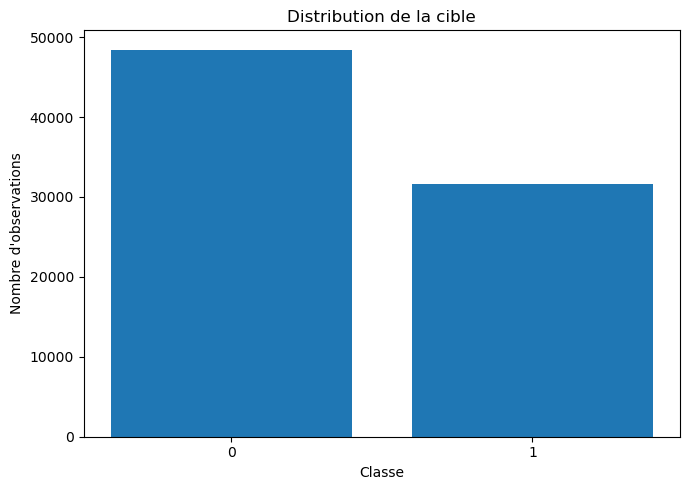

In [64]:
labeled = target_df[target_df[TARGET].notna()].copy()
labeled[TARGET] = labeled[TARGET].astype(int)

target_distribution = (
    labeled[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("classe")
    .to_frame("count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(labeled) * 100
)

display(target_distribution)

baseline = labeled[TARGET].value_counts(normalize=True).max()
print(f"Baseline classe majoritaire : {baseline:.2%}")

plt.figure(figsize=(7, 5))
plt.bar(target_distribution.index.astype(str), target_distribution["count"])
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la cible")
plt.tight_layout()
plt.show()




### Baseline

Parmi les observations disposant d’un véritable T+1, la classe majoritaire représente environ **60,51 %** des observations.

Un modèle qui afficherait seulement 60–61 % d’accuracy n’apporterait pratiquement aucune valeur par rapport à une prédiction naïve. L’évaluation doit prioriser le **Recall de la classe 1**, la Precision, le F1-score, la PR-AUC et la matrice de confusion.


,year,n,positive_rate,positive_rate_pct
0,2000,2369,0.432,43.183
1,2001,2304,0.408,40.755
2,2002,2555,0.348,34.834
3,2003,2570,0.287,28.716
4,2004,2478,0.309,30.872
5,2005,222,0.365,36.486
6,2006,2096,0.325,32.490
7,2007,2192,0.410,40.967
8,2008,2621,0.425,42.465
9,2009,2398,0.372,37.239


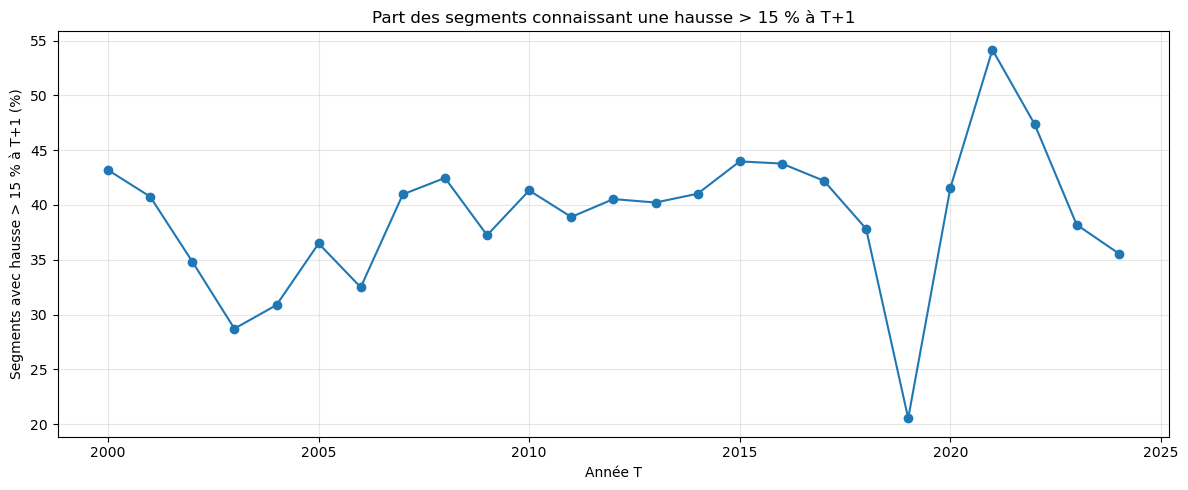

In [65]:
target_by_year = (
    labeled.groupby("year", as_index=False)
    .agg(
        n=(TARGET, "size"),
        positive_rate=(TARGET, "mean")
    )
)

target_by_year["positive_rate_pct"] = target_by_year["positive_rate"] * 100

display(target_by_year)

plt.figure(figsize=(12, 5))
plt.plot(
    target_by_year["year"],
    target_by_year["positive_rate_pct"],
    marker="o"
)
plt.xlabel("Année T")
plt.ylabel("Segments avec hausse > 15 % à T+1 (%)")
plt.title("Part des segments connaissant une hausse > 15 % à T+1")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


`Part des hausses critiques à T+1`|

La proportion de segments connaissant une hausse supérieure à 15 % à T+1 varie fortement selon l’année : environ **20,5 % en 2019**, **41,5 % en 2020**, **54,2 % en 2021**, **47,4 % en 2022** et **35,6 % en 2024**.

**Interprétation :** la probabilité de hausse critique n’est pas stable dans le temps.

**Implication ML :** une séparation aléatoire Train/Test risquerait de mélanger des régimes temporels différents. Le split doit donc être chronologique.


La fréquence de la classe positive varie fortement selon l’année. Dans l’EDA initiale, elle passe notamment d’environ **20,5 % en 2019** à **54,2 % en 2021**, puis environ **35,6 % en 2024**.

**Implication ML :** le phénomène n’est pas temporellement stable. Une séparation aléatoire Train/Test risquerait de produire une évaluation trop optimiste ; la validation doit donc respecter la chronologie.


In [66]:
signals = [
    "applied",
    "applied_lag1",
    "applied_lag2",
    "growth_past_1",
    "growth_past_2",
    "decisions_total",
    "refugee_recognition_rate",
    "protection_rate",
    "idmc_total_origin"
]
signals = [c for c in signals if c in labeled.columns]

signal_summary = (
    labeled.groupby(TARGET)[signals]
    .median(numeric_only=True)
    .T
)

signal_summary.columns = [
    "classe_0_mediane",
    "classe_1_mediane"
]

display(signal_summary)


,classe_0_mediane,classe_1_mediane
applied,37.000,22.000
applied_lag1,37.000,25.000
applied_lag2,37.000,27.000
growth_past_1,0.017,0.000
growth_past_2,0.000,0.000
decisions_total,41.000,27.000
refugee_recognition_rate,0.007,0.000
protection_rate,0.061,0.077
idmc_total_origin,"350,000.000","400,000.000"


### 11. Variables explicatives candidates

In [67]:
categorical_features = [
    "coo_id", "coa_id",
    "procedure_type", "app_type",
    "dec_level", "app_pc",
    "origin_region", "asylum_region"
]

numeric_features = [
    "year",
    "applied",

    # Historique du segment
    "applied_lag1",
    "applied_lag2",
    "growth_past_1",
    "growth_past_2",
    "two_consecutive_increases",

    # Décisions
    "decisions_recognized",
    "decisions_other",
    "decisions_rejected",
    "decisions_closed",
    "decisions_total",
    "refugee_recognition_rate",
    "protection_rate",
    "rejection_rate",

    # Contexte IDMC
    "idmc_total_origin"
]
categorical_features = [
    c for c in categorical_features
    if c in labeled.columns
]

numeric_features = [
    c for c in numeric_features
    if c in labeled.columns
]

print("Catégorielles candidates :", categorical_features)
print("Numériques candidates :", numeric_features)

excluded_features = [
    "_row_id", "_demand_row_id",
    "decisions_source_rows", "solutions_source_rows",
    "year_t1", "applied_t1", "growth_t1",
    TARGET
]

print("\nÀ exclure des features :")
print(excluded_features)

Catégorielles candidates : ['coo_id', 'coa_id', 'procedure_type', 'app_type', 'dec_level', 'app_pc', 'origin_region', 'asylum_region']
Numériques candidates : ['year', 'applied', 'applied_lag1', 'applied_lag2', 'growth_past_1', 'growth_past_2', 'two_consecutive_increases', 'decisions_recognized', 'decisions_other', 'decisions_rejected', 'decisions_closed', 'decisions_total', 'refugee_recognition_rate', 'protection_rate', 'rejection_rate', 'idmc_total_origin']

À exclure des features :
['_row_id', '_demand_row_id', 'decisions_source_rows', 'solutions_source_rows', 'year_t1', 'applied_t1', 'growth_t1', 'hausse_critique_demandes_t1']


Décision Feature Set

Les variables temporelles `(applied_lag1, applied_lag2, growth_past_1, growth_past_2, two_consecutive_increases)` sont retenues comme features candidates afin de représenter l’historique et la persistance des évolutions. Les variables de solutions sont écartées de la V1 en raison de leur forte incomplétude, tandis que les identifiants techniques et toutes les variables futures `(year_t1, applied_t1, growth_t1, cible)` sont exclues afin d’éviter toute fuite de cible (target leakage).

Les variables relatives aux `décisions d’asile et idmc_total_origin` restent candidates sous condition : elles ne seront utilisées que si elles sont réellement disponibles au moment du scoring à T. Dans le cas contraire, elles devront être décalées (lag) ou exclues. Le Feature Set privilégie ainsi uniquement les informations réellement disponibles à T et dans le passé.

### 7. Corrélations numériques avec la cible

,spearman_with_target
applied,-0.131
decisions_total,-0.096
applied_lag1,-0.088
decisions_closed,-0.082
decisions_rejected,-0.082
applied_lag2,-0.077
growth_past_1,-0.055
two_consecutive_increases,-0.038
growth_past_2,-0.036
year,0.024


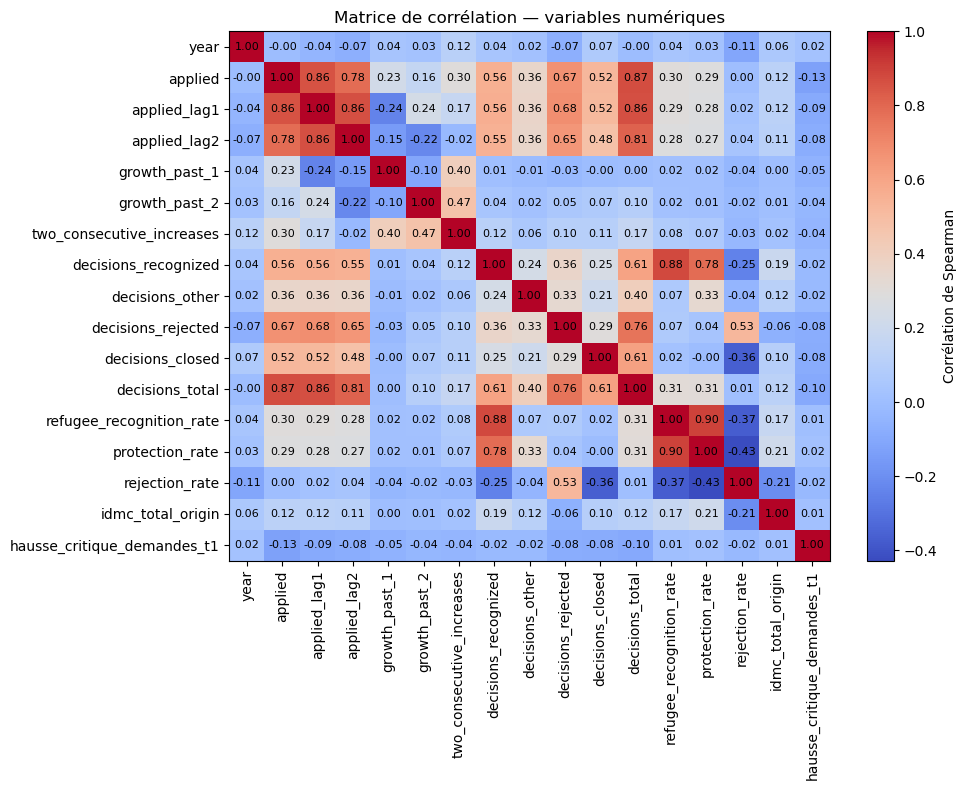

In [68]:
corr_cols = numeric_features + [TARGET]

corr = (
    labeled[corr_cols]
    .corr(method="spearman")
)

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .to_frame("spearman_with_target")
)

display(target_corr.round(3))


# Correlation heatmap

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr.values, aspect="auto",cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):

        value = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )



fig.colorbar(im, ax=ax, label="Corrélation de Spearman")
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()


Plusieurs variables explicatives sont fortement corrélées entre elles, notamment applied avec `applied_lag1 (0,86)` et `decisions_total (0,87)`, ainsi que `refugee_recognition_rate avec protection_rate (0,90)`. Cette redondance devra être prise en compte lors de la modélisation.

In [69]:
for col in ["recognition_rate", "rejection_rate"]:
    if col in df.columns:
        valid = df[col].dropna()
        print(
            col,
            "| < 0 :", int((valid < 0).sum()),
            "| > 1 :", int((valid > 1).sum()),
            "| max :", valid.max()
        )

if "rejection_rate" in df.columns:
    display(
        df.loc[
            df["rejection_rate"] > 1,
            [
                "year", "coo_id", "coa_id",
                "procedure_type", "dec_level",
                "decisions_rejected",
                "decisions_total",
                "rejection_rate"
            ]
        ]
    )


recognition_rate | < 0 : 0 | > 1 : 0 | max : 1.0
rejection_rate | < 0 : 0 | > 1 : 1 | max : 1.0395569620253164


,year,coo_id,coa_id,procedure_type,dec_level,decisions_rejected,decisions_total,rejection_rate
8114,2020,262,33,G,AR,657.000,632.000,1.040


### 11. Audit anti-leakage

Toute feature doit être disponible au moment réel du scoring.

| Variable | Utilisable ? | Condition |
|---|---|---|
| `year` | Oui | disponible à T |
| `applied` | Oui | disponible à T |
| `applied_lag1`, `lag2` | Oui | historique |
| croissance passée | Oui | calculée uniquement avec passé/T |
| pays/régions | Oui | référentiels connus |
| `idmc_total_origin` | Sous condition | doit être publié/disponible à T |
| décisions de l’année T | Sous condition | dépend du moment du scoring |
| `year_t1` | Non | futur |
| `applied_t1` | Non | futur |
| `growth_t1` | Non | futur |
| cible | Non | résultat à prédire |

Les variables de décisions de T doivent être décalées si elles ne sont connues qu’après le moment où la prédiction doit être produite.


### 12. Préparation Machine Learning

### Classification principale

**Cible :** `hausse_critique_demandes_t1`

Métriques prioritaires :
- Recall classe 1 ;
- Precision classe 1 ;
- F1 ;
- PR-AUC ;
- matrice de confusion.

Une baseline naïve de classe majoritaire doit être calculée avant tout modèle.

## Régression secondaire

**Cible :** `applied_t1`

Métriques possibles :
- MAE ;
- RMSE ;
- MAPE uniquement avec prudence lorsque les volumes sont faibles.

## Validation

Le split doit être **chronologique**, jamais aléatoire comme méthode principale :

`Passé → Train → Validation → Futur → Test`
